# Nasdaq War Analysis Pt. 2 (SNP500)

## Background

In Part 1, we analyzed the impact of four major wars on the NASDAQ Composite Index by comparing average daily returns during each war period against the 50 year historical average. A two-tailed z-test was applied to determine statistical significance.

Across all four wars (the Gulf War, Iraq War, Afghanistan War, and the Russia-Ukraine War), the results consistently failed to reject the null hypothesis, suggesting that war periods as a whole did not produce statistically significant differences in NASDAQ returns.

Several factors explain this outcome. First, wars such as the Iraq War (8 years) and the Afghanistan War (20 years) spanned such long timeframes that their effects became diluted by unrelated macroeconomic events, including the dot-com bubble collapse, the 2008 financial crisis, and the post-pandemic AI boom. Second, markets often price in conflict before it is officially declared. In the Iraq War, NASDAQ had already dropped significantly by the time the invasion began in March 2003, as tension had been building since Bush's UN address in September 2002.

These findings suggest that analyzing war periods as a whole is not a meaningful approach. A more precise method would be to isolate specific moments of uncertainty, when conflict begins and when it resolves, and observe how markets respond in the immediate aftermath. This is the focus of Part 2.


## Hypothesis

Rather than the duration of war itself, it is the moments of peak uncertainty and its
resolution that drive measurable market reactions.

Specifically, we hypothesize the following:

- **Uncertainty Start**: When a conflict begins or escalates unexpectedly, investor
  uncertainty rises sharply. This should produce a measurable decline in the S&P 500
  over the following 14 trading days.

- **Uncertainty Resolution**: When a decisive event occurs that significantly reduces
  ambiguity around the conflict (such as a military intervention, ceasefire, or clear
  shift in momentum), investor confidence recovers. This should produce a measurable
  rise in the S&P 500 over the following 14 trading days.

If this hypothesis holds across multiple wars, it would suggest that markets react not
to war as a prolonged state, but to the information shocks embedded within it.

## Methodology

**Data**: S&P 500 index (^GSPC) sourced from Yahoo Finance, covering the past 50 years.
The S&P 500 is used in place of the NASDAQ Composite from Part 1, as it provides a broader
representation of the overall U.S. economy and is less concentrated in the technology sector.

**Event Selection**: For each war, two key events are identified:
- The moment uncertainty begins (e.g., invasion, attack, or declaration of war)
- The moment uncertainty is most significantly resolved (e.g., military intervention,
  ceasefire, or a decisive shift in momentum)

**Analysis Window**: Returns are measured over the 14 trading days following each event.
The closing price on the event date is set as the baseline (Day 0), and cumulative
returns are tracked through Day 14.

**Expected Direction**:
- Uncertainty start: negative return over 14 trading days
- Uncertainty resolution: positive return over 14 trading days

**Wars Covered**:
1. Gulf War (1990-1991)
2. Iraq War (2003-2011)
3. War in Afghanistan (2001-2021)
4. Russia-Ukraine War (2022-present)

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats


In [2]:
snp500 = yf.download('^GSPC', period = "50y")
snp500.columns = snp500.columns.get_level_values(0)
snp500 = snp500.reset_index()
snp500["Daily Return"] = snp500["Close"].pct_change() * 100
snp500

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume,Daily Return
0,1976-06-07,98.629997,99.389999,97.970001,99.150002,14510000,NaN
1,1976-06-08,98.800003,99.709999,98.320000,98.629997,16660000,0.172367
2,1976-06-09,98.739998,99.489998,98.230003,98.800003,14560000,-0.060734
3,1976-06-10,99.559998,99.980003,98.550003,98.739998,16100000,0.830464
4,1976-06-11,100.919998,101.220001,99.379997,99.559998,19470000,1.366011
...,...,...,...,...,...,...,...
12599,2026-06-01,7599.959961,7617.660156,7562.609863,7582.290039,6583960000,0.262530
12600,2026-06-02,7609.779785,7620.899902,7582.990234,7595.399902,5904410000,0.129209
12601,2026-06-03,7553.680176,7605.350098,7551.220215,7605.310059,5753860000,-0.737204
12602,2026-06-04,7584.310059,7598.189941,7516.540039,7516.540039,5398910000,0.405496


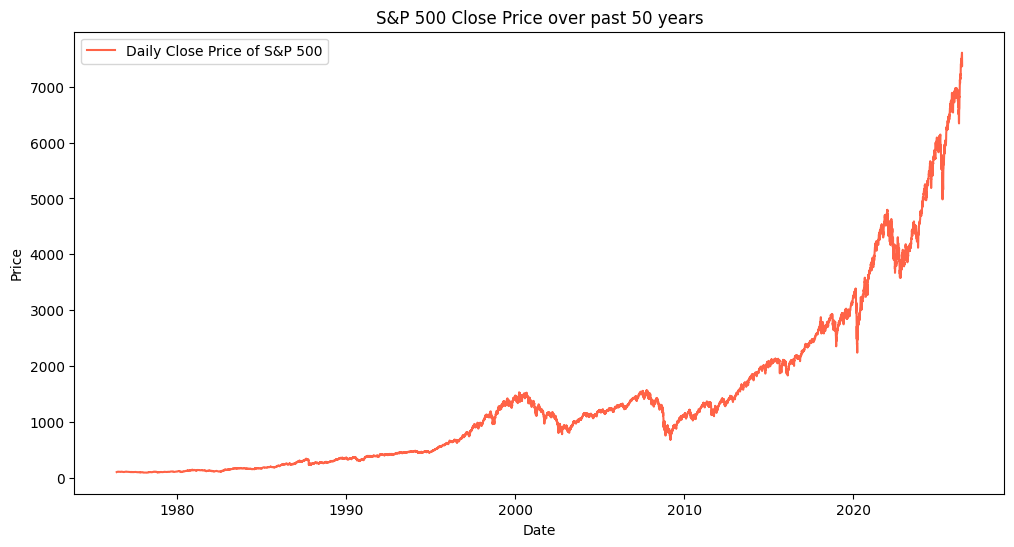

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(snp500["Date"], snp500["Close"], label="Daily Close Price of S&P 500", color="tomato")
plt.title("S&P 500 Close Price over past 50 years")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# Gulf War

Gulf War Timeline

1990-08-02 — Iraq invades Kuwait

1990-08-07 — US deploys troops to Saudi Arabia (Operation Desert Shield)

1990-11-29 — UN issues ultimatum to Iraq: withdraw by 1991-01-15

1991-01-15 — UN deadline expires

1991-01-17 — US-led coalition launches air strikes on Iraq (Operation Desert Storm)

1991-02-24 — Ground offensive begins

1991-02-28 — Bush declares ceasefire, war ends


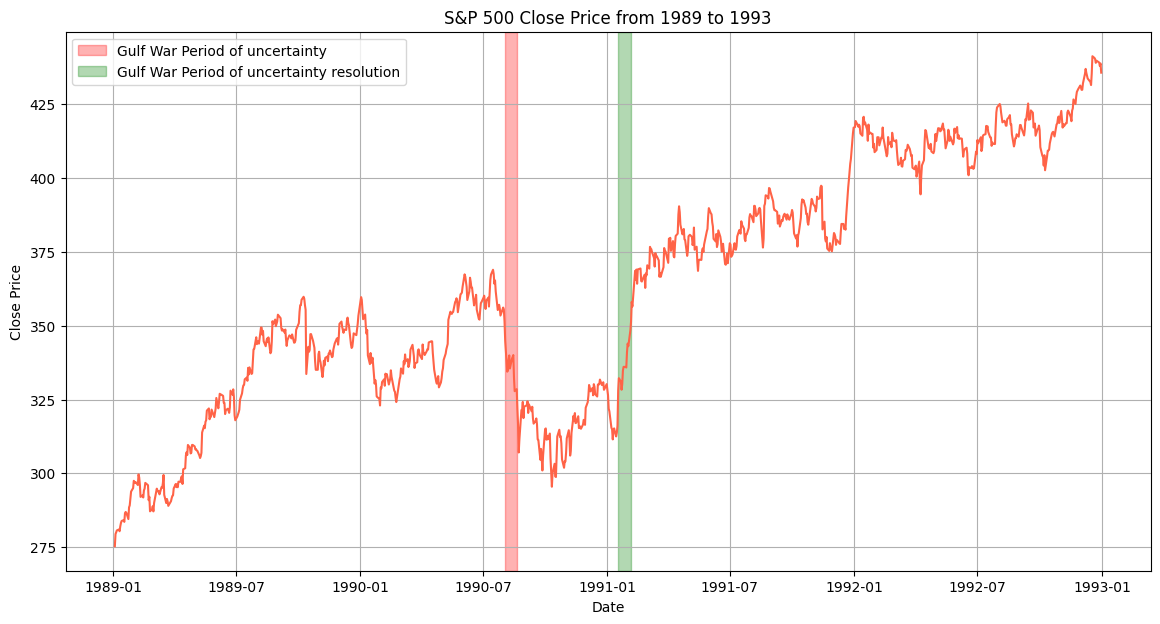

In [4]:
uncertainty_begin = "1990-08-02"
uncertainty_resolve = "1991-01-17"
begin14 = snp500[snp500["Date"] >= uncertainty_begin].iloc[13]["Date"]
resolve14 = snp500[snp500["Date"] >= uncertainty_resolve].iloc[13]["Date"]
plt.figure(figsize=(14, 7))
mask = (snp500["Date"] >= "1989-01-01") & (snp500["Date"] <= "1993-01-01")
plt.plot(snp500[mask]["Date"], snp500[mask]["Close"], color="tomato")
plt.axvspan(uncertainty_begin, begin14, alpha=0.3, color="red", label="Gulf War Period of uncertainty")
plt.axvspan(uncertainty_resolve, resolve14, alpha=0.3, color="green", label="Gulf War Period of uncertainty resolution")
plt.legend()
plt.title("S&P 500 Close Price from 1989 to 1993")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid()
plt.show()

In [5]:
begin14_pctchange = snp500[snp500["Date"] >= uncertainty_begin].head(14)["Daily Return"].mean()
begin14_pctchange
resolve14_pctchange = snp500[snp500["Date"] >= uncertainty_resolve].head(14)["Daily Return"].mean()
resolve14_pctchange

print(f"Average daily return during the 14 trading days after the start of the Gulf War uncertainty: {begin14_pctchange:.4f}%")
print(f"Average daily return during the 14 trading days after the resolution of the Gulf War uncertainty: {resolve14_pctchange:.4f}%")


Average daily return during the 14 trading days after the start of the Gulf War uncertainty: -0.6999%
Average daily return during the 14 trading days after the resolution of the Gulf War uncertainty: 0.7606%


## Iraq War

Iraq War Timeline

2002-09-12 — Bush addresses UN, warns of Iraq threat

2002-10-16 — US Congress authorizes use of military force against Iraq

2003-02-05 — Colin Powell presents evidence of WMDs at UN

2003-03-17 — Bush issues 48-hour ultimatum to Saddam Hussein

2003-03-20 — US-led coalition invades Iraq

2003-04-09 — Baghdad falls, Saddam statue toppled

2003-05-01 — Bush declares "Mission Accomplished"

2008-09-15 — Lehman Brothers collapse (financial crisis begins)

2011-12-15 — US military formally withdraws from Iraq, war ends


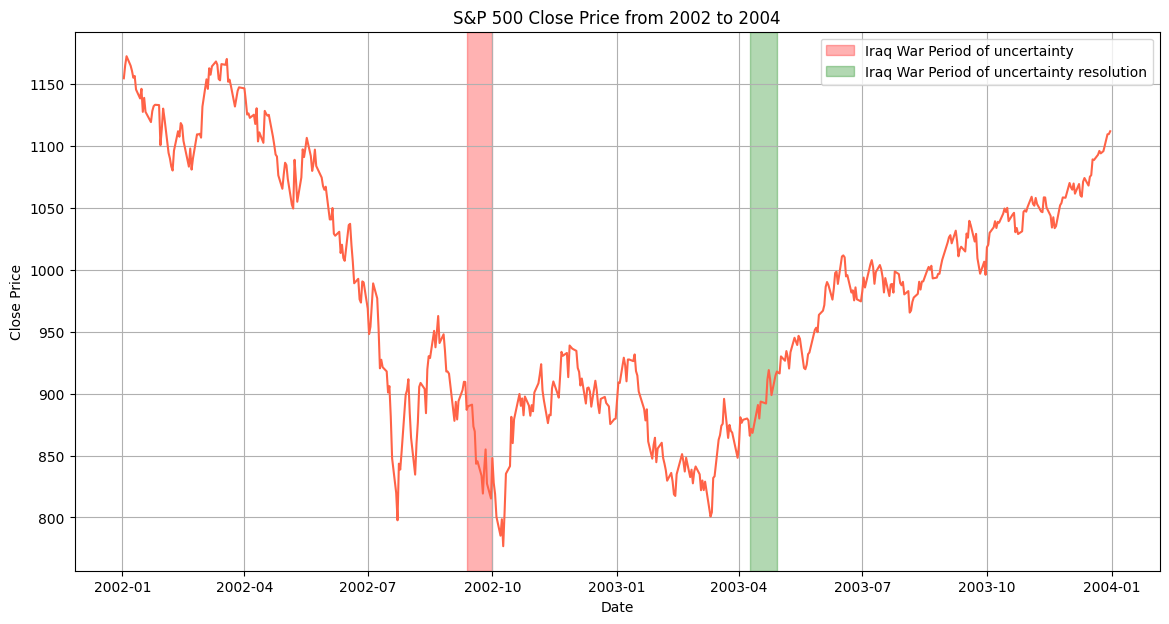

In [6]:
# Uncertainty rose on September 12, 2002, when the US government issued a warning about potential threats from Iraq, and it was resolved on March 20, 2003, when the US launched its invasion of Iraq. Let's analyze the S&P 500 performance during these periods.
uncertainty_begin = "2002-09-12"
# Uncertainty resolved on April 9, 2003, when President Bush declared the end of major combat operations in Iraq.
uncertainty_resolve = "2003-04-09"
begin14 = snp500[snp500["Date"] >= uncertainty_begin].iloc[13]["Date"]
resolve14 = snp500[snp500["Date"] >= uncertainty_resolve].iloc[13]["Date"]
plt.figure(figsize=(14, 7))
mask = (snp500["Date"] >= "2002-01-01") & (snp500["Date"] <= "2004-01-01")
plt.plot(snp500[mask]["Date"], snp500[mask]["Close"], color="tomato")
plt.axvspan(uncertainty_begin, begin14, alpha=0.3, color="red", label="Iraq War Period of uncertainty")
plt.axvspan(uncertainty_resolve, resolve14, alpha=0.3, color="green", label="Iraq War Period of uncertainty resolution")
plt.legend()
plt.title("S&P 500 Close Price from 2002 to 2004")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid()
plt.show()

In [7]:
begin14_pctchange = snp500[snp500["Date"] >= uncertainty_begin].head(14)["Daily Return"].mean()
begin14_pctchange
resolve14_pctchange = snp500[snp500["Date"] >= uncertainty_resolve].head(14)["Daily Return"].mean()
resolve14_pctchange

print(f"Average daily return during the 14 trading days after the start of the Iraq War uncertainty: {begin14_pctchange:.4f}%")
print(f"Average daily return during the 14 trading days after the resolution of the Iraq War uncertainty: {resolve14_pctchange:.4f}%")


Average daily return during the 14 trading days after the start of the Iraq War uncertainty: -0.4781%
Average daily return during the 14 trading days after the resolution of the Iraq War uncertainty: 0.3224%


## War in Afghanistan

Afghanistan War Timeline

2001-09-11 — Al-Qaeda terrorist attacks on US soil (9/11)

2001-09-20 — Bush declares War on Terror, issues ultimatum to Taliban

2001-10-07 — US-led coalition invades Afghanistan (Operation Enduring Freedom)

2001-11-13 — Taliban regime falls, Kabul captured

2009-02-17 — Obama approves troop surge

2011-05-02 — Osama bin Laden killed in Pakistan

2014-12-28 — US formally ends combat mission

2021-08-15 — Taliban retakes Kabul

2021-08-30 — US completes full military withdrawal, war ends


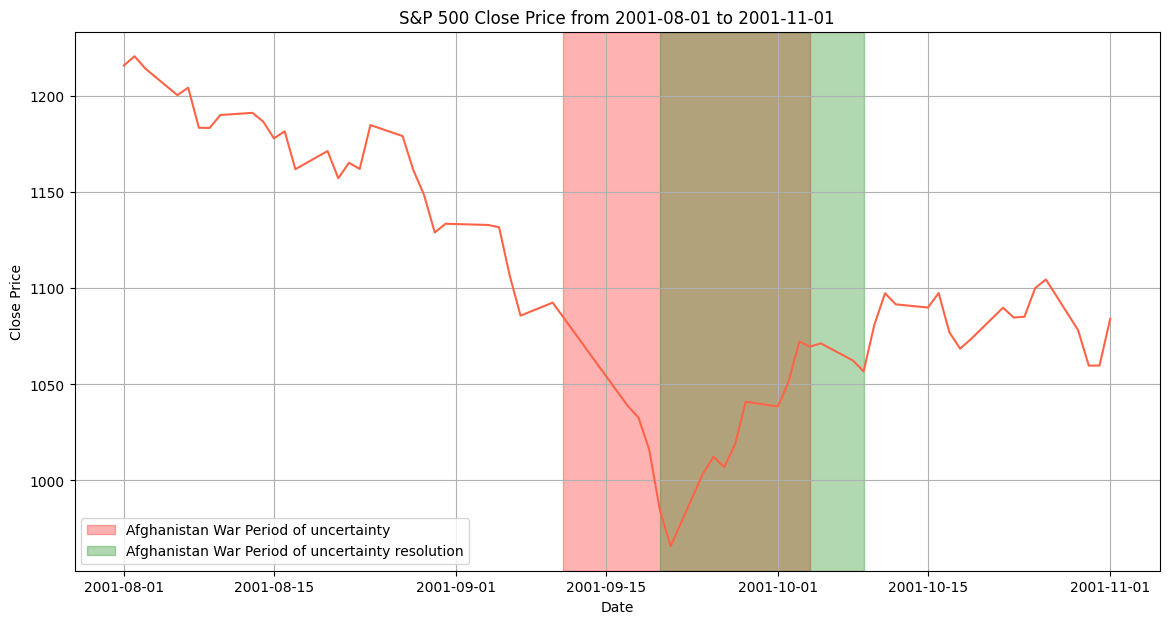

In [14]:
# Uncertainty rose on September 11, 2001, when the 9/11 terrorist attacks occurred.
uncertainty_begin = "2001-09-11"
# Uncertainty resolved on September 20, 2001, when the initial uncertainty period ended.
uncertainty_resolve = "2001-09-20"
begin14 = snp500[snp500["Date"] >= uncertainty_begin].iloc[13]["Date"]
resolve14 = snp500[snp500["Date"] >= uncertainty_resolve].iloc[13]["Date"]
plt.figure(figsize=(14, 7))
mask = (snp500["Date"] >= "2001-08-01") & (snp500["Date"] <= "2001-11-01")
plt.plot(snp500[mask]["Date"], snp500[mask]["Close"], color="tomato")
plt.axvspan(uncertainty_begin, begin14, alpha=0.3, color="red", label="Afghanistan War Period of uncertainty")
plt.axvspan(uncertainty_resolve, resolve14, alpha=0.3, color="green", label="Afghanistan War Period of uncertainty resolution")
plt.legend()
plt.title("S&P 500 Close Price from 2001-08-01 to 2001-11-01")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid()
plt.show()

In [9]:
begin14_pctchange = snp500[snp500["Date"] >= uncertainty_begin].head(14)["Daily Return"].mean()
begin14_pctchange
resolve14_pctchange = snp500[snp500["Date"] >= uncertainty_resolve].head(14)["Daily Return"].mean()
resolve14_pctchange

print(f"Average daily return during the 14 trading days after the start of the Afghanistan War uncertainty: {begin14_pctchange:.4f}%")
print(f"Average daily return during the 14 trading days after the resolution of the Afghanistan War uncertainty: {resolve14_pctchange:.4f}%")


Average daily return during the 14 trading days after the start of the Afghanistan War uncertainty: -0.1267%
Average daily return during the 14 trading days after the resolution of the Afghanistan War uncertainty: 0.2952%


## Russia-Ukraine War (Ongoing)

Russia-Ukraine War Timeline

2022-02-24 — Russia launches full-scale invasion of Ukraine

2022-02-26 — Russia removed from SWIFT international banking system

2022-03-08 — US bans Russian oil imports

2022-09-06 — Ukraine launches Kharkiv counteroffensive, recaptures significant territory

2023-06-04 — Ukraine launches major counteroffensive (largely unsuccessful)

2024-11-05 — Trump re-elected, raising hopes for ceasefire negotiations

2025-03 — US-brokered ceasefire talks begin

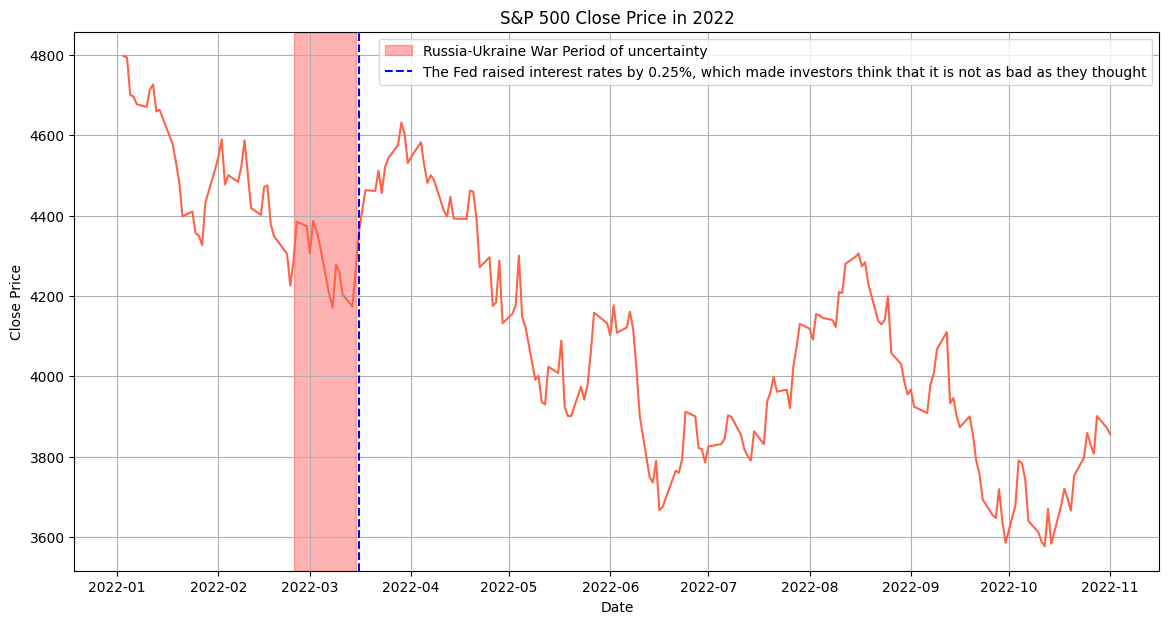

In [12]:
# Uncertainty  rose on February 24, 2022, when Russia launched its invasion of Ukraine, and it has not been resolved yet. Let's analyze the S&P 500 performance during the uncertainty period.
# Uncertainty has not been resolved yet, but we can analyze the S&P 500 performance during the uncertainty period.
uncertainty_begin = "2022-02-24"
begin14 = snp500[snp500["Date"] >= uncertainty_begin].iloc[13]["Date"]
# resolve14 = snp500[snp500["Date"] >= uncertainty_resolve].iloc[13]["Date"]
plt.figure(figsize=(14, 7))
mask = (snp500["Date"] >= "2022-01-01") & (snp500["Date"] <= "2022-11-01")
plt.plot(snp500[mask]["Date"], snp500[mask]["Close"], color="tomato")
plt.axvspan(uncertainty_begin, begin14, alpha=0.3, color="red", label="Russia-Ukraine War Period of uncertainty")
plt.axvline(x=pd.to_datetime("2022-03-16"), color="blue", linestyle="--", label="The Fed raised interest rates by 0.25%, which made investors think that it is not as bad as they thought")
plt.legend()
plt.title("S&P 500 Close Price in 2022")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid()
plt.show()

In [13]:
begin14_pctchange = snp500[snp500["Date"] >= uncertainty_begin].head(14)["Daily Return"].mean()
begin14_pctchange


print(f"Average daily return during the 14 trading days after the start of the Russia-Ukraine War uncertainty: {begin14_pctchange:.4f}%")


Average daily return during the 14 trading days after the start of the Russia-Ukraine War uncertainty: 0.0753%


## Results

In [18]:
avg_daily_return = snp500["Daily Return"].mean()
print(f"Average daily return of S&P 500 over the past 50 years: {avg_daily_return:.4f}%")
results = {
    "War": ["Gulf War", "Iraq War", "Afghanistan War", "Russia-Ukraine War"],
    "Uncertainty Begin (14d avg)": [-0.6999, -0.4781, -0.1267, 0.0753],
    "Uncertainty Resolve (14d avg)": [0.7606, 0.3224, 0.2952, None],
    "Average Daily Return (50y)": [avg_daily_return] * 4,
}
results_df = pd.DataFrame(results)
results_df

Average daily return of S&P 500 over the past 50 years: 0.0403%


,War,Uncertainty Begin (14d avg),Uncertainty Resolve (14d avg),Average Daily Return (50y)
0,Gulf War,-0.6999,0.7606,0.040301
1,Iraq War,-0.4781,0.3224,0.040301
2,Afghanistan War,-0.1267,0.2952,0.040301
3,Russia-Ukraine War,0.0753,NaN,0.040301


## Analysis

### Reasons for the range of periods of each events

**Gulf War**

Uncertainty begin: 1990-08-02 (Iraq invades Kuwait)
The invasion was an unexpected geopolitical shock that immediately raised questions about
US involvement, oil supply disruption, and regional stability. This date marks the clearest
point where investor uncertainty entered the market.

Uncertainty resolve: 1991-01-17 (US-led coalition launches air strikes)
Once the US-led coalition began Operation Desert Storm, the ambiguity over whether and how
the US would respond was eliminated. Markets reacted sharply upward on this date, consistent
with uncertainty being resolved rather than the war ending.

**Iraq War**

Uncertainty begin: 2002-09-12 (Bush addresses UN, warns of Iraq threat)
The market began pricing in the possibility of war on this date, months before the actual
invasion. This is supported by the sustained decline in S&P 500 from September 2002 onward.

Uncertainty resolve: 2003-04-09 (Baghdad falls, Saddam statue toppled)
The rapid fall of Baghdad signaled that major combat was effectively over. Markets began
recovering from this point, preceding the formal "Mission Accomplished" declaration by
nearly a month. The Iraq War period also overlaps with the dot-com bubble collapse and the
WorldCom/Enron accounting scandals, making it difficult to fully isolate the war's impact.

**War in Afghanistan**

Uncertainty begin: 2001-09-11 (9/11 terrorist attacks)
The attacks created sudden and severe uncertainty, with markets closing for four trading
days and dropping sharply upon reopening.

Uncertainty resolve: 2001-09-20 (Bush declares War on Terror)
Bush's address to Congress provided a clear policy direction, which was sufficient to
stabilize investor sentiment. The 14-day windows for begin and resolve overlap due to the
short gap between these two events. This reflects the nature of the 9/11 shock, where
uncertainty was extreme but resolved unusually quickly compared to other wars.

**Russia-Ukraine War**

Uncertainty begin: 2022-02-24 (Russia launches full-scale invasion of Ukraine)
No uncertainty resolve date is assigned as the war remains ongoing. A significant portion
of the S&P 500 decline during this period is attributed to the Federal Reserve's aggressive
rate hike cycle, which began on 2022-03-16. Russia's invasion worsened inflation through
energy and food price shocks, indirectly contributing to the Fed's decision to raise rates
more aggressively. The direct market impact of the war is therefore difficult to isolate.

In [25]:
population_mean = avg_daily_return
population_std = snp500["Daily Return"].std()

# left tailed because we expect negative returns during the uncertainty period
zscore_uncertainty_begin = (((-0.6999 + -0.4781 + -0.1267 + 0.0753) / 4) - population_mean) / (population_std / (14 * 4) ** 0.5)
p_value_uncertainty_begin = stats.norm.cdf(zscore_uncertainty_begin)
print(f"p-value for the 14-day average daily returns after the start of war uncertainties: {p_value_uncertainty_begin:.4f}")

# right tailed because we expect positive returns after the resolution of uncertainty
zscore_uncertainty_resolve = (((0.7606 + 0.3224 + 0.2952) / 3) - population_mean) / (population_std / (14 * 3) ** 0.5)
p_value_uncertainty_resolve = 1 - stats.norm.cdf(zscore_uncertainty_resolve)
print(f"p-value for the 14-day average daily returns after the resolution of war uncertainties: {p_value_uncertainty_resolve:.4f}")

p-value for the 14-day average daily returns after the start of war uncertainties: 0.0089
p-value for the 14-day average daily returns after the resolution of war uncertainties: 0.0066


The analyzed p-values of average daily returns during the 14 trading days after the start and resolution of war uncertainties are both below the significance level of 0.05, leading us to reject the null hypothesis. This suggests there is sufficient evidence to claim that the start of war uncertainty is associated with a statistically significant decline in S&P 500 returns, and that the resolution of war uncertainty is associated with a statistically significant recovery.


## Limitations and Improvements

### Limitations

Although the results support the alternative hypothesis, there are several limitations that should be noted.

First, the Iraq War period overlaps with the dot-com bubble collapse and the WorldCom and Enron accounting scandals of 2002. These events likely contributed to the market decline along with the uncertainty begin period of the war. This event makes it difficult to analyze the sole effect of war-related uncertainty of Iraq war.

Second, in case of Russia-Ukraine War, a large portion of the uncertainty had already been priced in before the official invasion date of February 24, 2022. Russian troop buildups along the Ukrainian border had been widely reported since late 2021, and the S&P 500 had already been declining from January 2022 onward. Also, the fed's rate raise impacted the market to decline, making it more difficult to isolate the war's direct impact on market returns.

Third, the sample size of four wars limits the generalizability of the findings. While the results are statistically significant, drawing broad conclusions from four events carries inherent risk.


### Improvements

Including more wars in the analysis would strengthen the generalizability of the findings. Additionally, this study used a fixed 14-day window, and it would be worth exploring whether different time windows produce more or less significant results.